# Oleaje elevado y restricciones operativas en Gijón y Bilbao

Este notebook calcula las **horas mensuales con altura significativa de ola $Hs \geq 3$ m**, las compara con los tráficos y las horas de restricción, y ajusta una función lineal específica para cada puerto.

**Alcance:** análisis histórico y validación 2005–2024. La predicción de 2027 se realizará en un notebook posterior, utilizando como entrada la serie mensual de horas con $Hs \geq 3$ m generada aquí.


## 1. Preparación

En Google Colab, sube los tres CSV cuando aparezca la ventana. Si ya los has subido a `/content`, la celda los detectará automáticamente.


In [ ]:
import os
import glob
import calendar
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


In [ ]:
# Ejecuta esta celda en Colab para cargar los tres CSV.
# Si los archivos ya están en /content, no se abrirá el selector.
required_names = ['dataset_principal_oleaje', 'trafico_portuario_gijon', 'trafico_portuario_bilbao']
available = glob.glob('/content/*.csv')

if not all(any(name in Path(f).name.lower() for f in available) for name in required_names):
    from google.colab import files
    uploaded = files.upload()
    available = glob.glob('/content/*.csv')

def find_csv(fragment):
    matches = [f for f in available if fragment.lower() in Path(f).name.lower()]
    if not matches:
        raise FileNotFoundError(f'No se encontró un CSV que contenga: {fragment}')
    return matches[0]

path_oleaje = find_csv('dataset_principal_oleaje')
path_gijon = find_csv('trafico_portuario_gijon')
path_bilbao = find_csv('trafico_portuario_bilbao')

print('Oleaje:', Path(path_oleaje).name)
print('Gijón:', Path(path_gijon).name)
print('Bilbao:', Path(path_bilbao).name)


Oleaje: dataset_principal_oleaje.csv
Gijón: trafico_portuario_gijon_pes_revisado.csv
Bilbao: trafico_portuario_bilbao_pes_revisado.csv


## 2. Carga y construcción del indicador mensual

Se emplean las boyas costeras próximas a cada puerto: **Gijón Costera (1117)** y **Bilbao Costera (1103)**. Un mes se conserva solo si dispone de al menos el 70 % de sus horas teóricas; así, una ausencia de mediciones no se interpreta erróneamente como ausencia de oleaje alto.


In [ ]:
oleaje = pd.read_csv(path_oleaje, parse_dates=['fecha'])
trafico_gijon = pd.read_csv(path_gijon)
trafico_bilbao = pd.read_csv(path_bilbao)

for tabla in (trafico_gijon, trafico_bilbao):
    tabla['mes'] = pd.to_datetime(tabla['mes'] + '-01')

print('Registros horarios de oleaje:', len(oleaje))
display(oleaje.groupby(['codigo_boya', 'nombre_boya']).agg(
    inicio=('fecha', 'min'), fin=('fecha', 'max'), registros=('Hs_m', 'size')
))


Registros horarios de oleaje: 610438


,,inicio,fin,registros
codigo_boya,nombre_boya,,,
1103,Bilbao costera,2005-01-01 00:00:00,2024-12-31 23:00:00,140991
1117,Gijón costera,2005-01-05 09:00:00,2024-12-31 23:00:00,150719
2136,Bilbao-Vizcaya,2005-01-01 00:00:00,2024-12-31 23:00:00,162793
2242,Cabo de Peñas,2004-12-31 00:00:00,2024-12-31 23:00:00,155935


In [ ]:
def horas_hs3_mensuales(df_oleaje, codigo_boya, cobertura_minima=0.70):
    """Devuelve horas mensuales observadas con Hs >= 3 m para una boya."""
    datos = df_oleaje.loc[df_oleaje['codigo_boya'].eq(codigo_boya), ['fecha', 'Hs_m']].copy()
    datos = datos.dropna(subset=['Hs_m']).sort_values('fecha')
    datos['mes'] = datos['fecha'].dt.to_period('M').dt.to_timestamp()
    datos['hs_ge_3m'] = datos['Hs_m'].ge(3)

    mensual = (datos.groupby('mes')
               .agg(horas_hs_ge_3m=('hs_ge_3m', 'sum'),
                    horas_observadas=('Hs_m', 'size'),
                    hs_media_m=('Hs_m', 'mean'),
                    hs_max_m=('Hs_m', 'max'))
               .reset_index())
    mensual['horas_teoricas'] = mensual['mes'].apply(
        lambda x: calendar.monthrange(x.year, x.month)[1] * 24
    )
    mensual['cobertura'] = mensual['horas_observadas'] / mensual['horas_teoricas']
    mensual = mensual.loc[mensual['cobertura'].ge(cobertura_minima)].copy()
    return mensual

exposicion_gijon = horas_hs3_mensuales(oleaje, codigo_boya=1117)
exposicion_bilbao = horas_hs3_mensuales(oleaje, codigo_boya=1103)

print('Meses válidos Gijón:', len(exposicion_gijon))
print('Meses válidos Bilbao:', len(exposicion_bilbao))
display(exposicion_gijon.head())


Meses válidos Gijón: 202
Meses válidos Bilbao: 185


,mes,horas_hs_ge_3m,horas_observadas,hs_media_m,hs_max_m,horas_teoricas,cobertura
0,2005-01-01,164,528,2.820,8.980,744,0.710
2,2005-03-01,11,737,1.327,3.510,744,0.991
3,2005-04-01,56,718,1.590,4.060,720,0.997
4,2005-05-01,0,739,1.036,2.290,744,0.993
5,2005-06-01,0,718,0.944,2.170,720,0.997


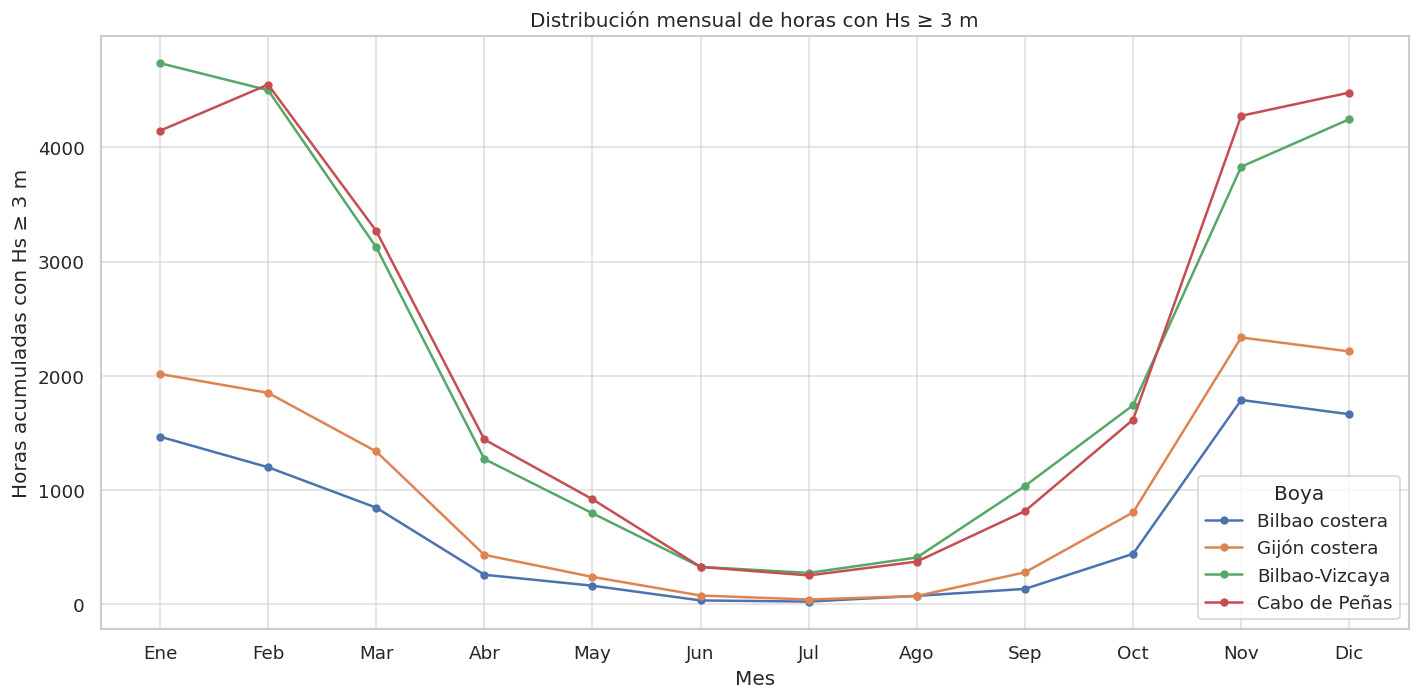

In [ ]:
# Distribución mensual acumulada de horas con Hs ≥ 3 m (2005–2024)
# Usa el dataframe "oleaje", ya cargado en el notebook.

orden_boyas = ['Bilbao costera', 'Gijón costera', 'Bilbao-Vizcaya', 'Cabo de Peñas']
colores = {
    'Bilbao costera': '#4C72B0',
    'Gijón costera': '#DD8452',
    'Bilbao-Vizcaya': '#55A868',
    'Cabo de Peñas': '#C44E52'
}
meses_etiqueta = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                  'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Cada registro horario cuyo Hs es igual o superior a 3 m cuenta como una hora
horas_mensuales_hs3 = (
    oleaje
    .dropna(subset=['fecha', 'Hs_m'])
    .assign(
        mes_num=lambda x: x['fecha'].dt.month,
        hora_hs_ge_3m=lambda x: x['Hs_m'].ge(3)
    )
    .groupby(['nombre_boya', 'mes_num'], as_index=False)['hora_hs_ge_3m']
    .sum()
    .rename(columns={'hora_hs_ge_3m': 'horas_hs_ge_3m'})
)

# Garantiza que aparezcan los doce meses en todas las boyas
indice_completo = pd.MultiIndex.from_product(
    [orden_boyas, range(1, 13)],
    names=['nombre_boya', 'mes_num']
)

horas_mensuales_hs3 = (
    horas_mensuales_hs3
    .set_index(['nombre_boya', 'mes_num'])
    .reindex(indice_completo, fill_value=0)
    .reset_index()
)

# Gráfico
plt.figure(figsize=(12, 6))

for boya in orden_boyas:
    datos = horas_mensuales_hs3[
        horas_mensuales_hs3['nombre_boya'] == boya
    ]
    plt.plot(
        datos['mes_num'],
        datos['horas_hs_ge_3m'],
        marker='o',
        markersize=4,
        linewidth=1.5,
        color=colores[boya],
        label=boya
    )

plt.xticks(range(1, 13), meses_etiqueta)
plt.xlabel('Mes')
plt.ylabel('Horas acumuladas con Hs ≥ 3 m')
plt.title('Distribución mensual de horas con Hs ≥ 3 m')
plt.legend(title='Boya')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

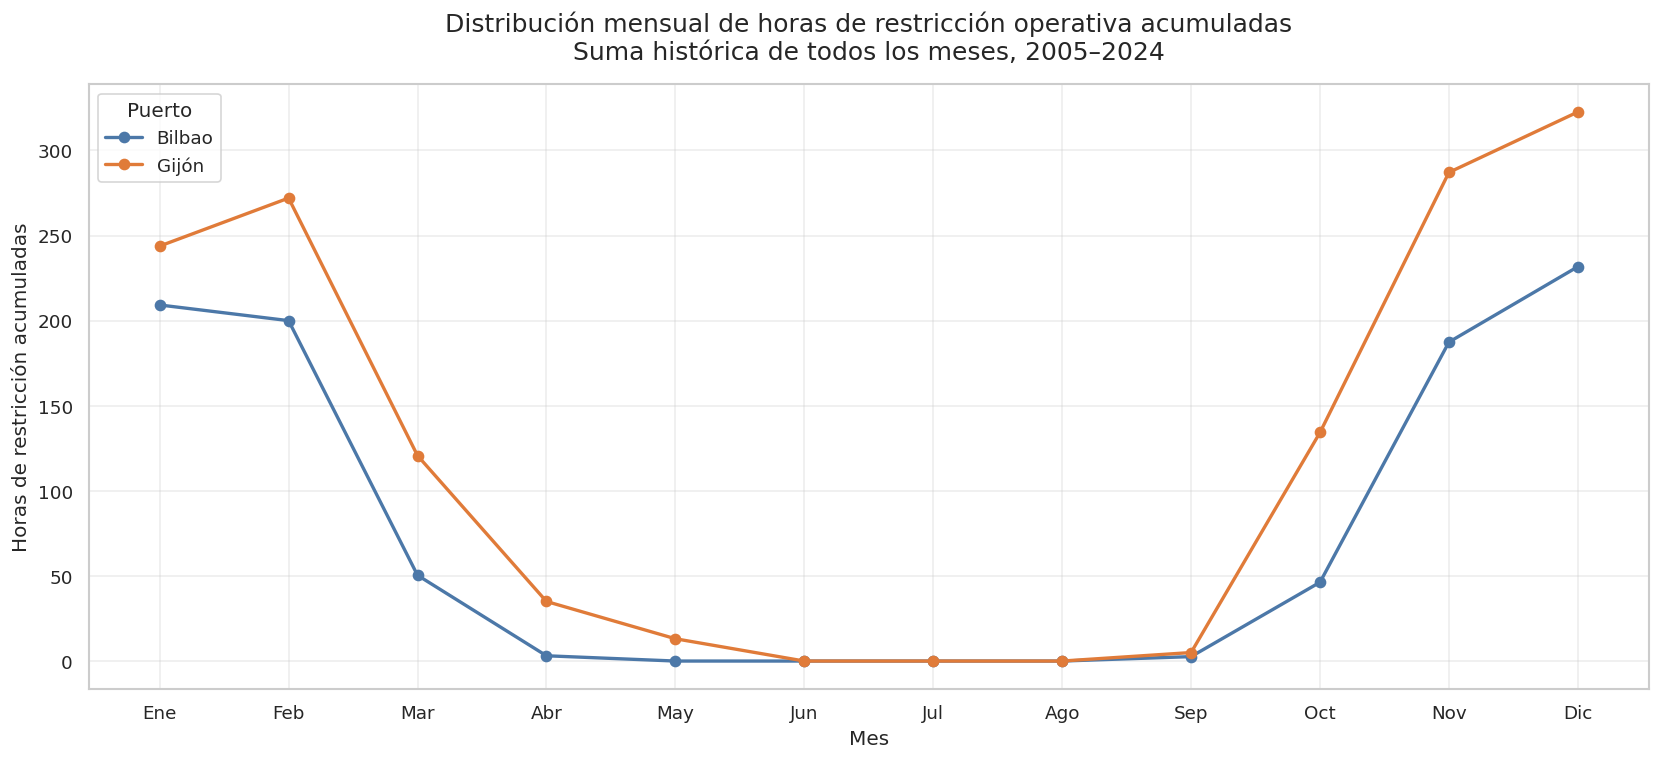

In [ ]:
# DISTRIBUCIÓN MENSUAL DE HORAS DE RESTRICCIÓN ACUMULADAS
# Suma de todos los eneros, febreros, etc. entre 2005 y 2024.
# Formato de líneas equivalente al gráfico de horas acumuladas con Hs ≥ 3 m.

import pandas as pd
import matplotlib.pyplot as plt

orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

def calcular_restricciones_acumuladas(trafico):
    datos = trafico[['mes', 'horas_restriccion']].copy()
    datos['mes'] = pd.to_datetime(datos['mes'])
    datos['mes_num'] = datos['mes'].dt.month

    perfil = (
        datos.groupby('mes_num', as_index=False)['horas_restriccion']
        .sum()
        .rename(columns={'horas_restriccion': 'restricciones_acumuladas'})
    )

    # Garantiza que se muestren enero–diciembre en el orden correcto
    perfil = (
        pd.DataFrame({'mes_num': range(1, 13)})
        .merge(perfil, on='mes_num', how='left')
        .fillna({'restricciones_acumuladas': 0})
    )

    perfil['mes_nombre'] = orden_meses
    return perfil

# Acumulados históricos para cada puerto
restricciones_acum_gijon = calcular_restricciones_acumuladas(trafico_gijon)
restricciones_acum_bilbao = calcular_restricciones_acumuladas(trafico_bilbao)

# Gráfico de líneas
plt.figure(figsize=(14, 6.5))

plt.plot(
    restricciones_acum_bilbao['mes_nombre'],
    restricciones_acum_bilbao['restricciones_acumuladas'],
    color='#4C78A8',
    marker='o',
    linewidth=2,
    markersize=6,
    label='Bilbao'
)

plt.plot(
    restricciones_acum_gijon['mes_nombre'],
    restricciones_acum_gijon['restricciones_acumuladas'],
    color='#E07B39',
    marker='o',
    linewidth=2,
    markersize=6,
    label='Gijón'
)

plt.title(
    'Distribución mensual de horas de restricción operativa acumuladas\n'
    'Suma histórica de todos los meses, 2005–2024',
    fontsize=15,
    pad=15
)

plt.xlabel('Mes', fontsize=12)
plt.ylabel('Horas de restricción acumuladas', fontsize=12)

plt.grid(True, linestyle='-', alpha=0.35)
plt.legend(title='Puerto', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_944/2134789693.py:16: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .sum()


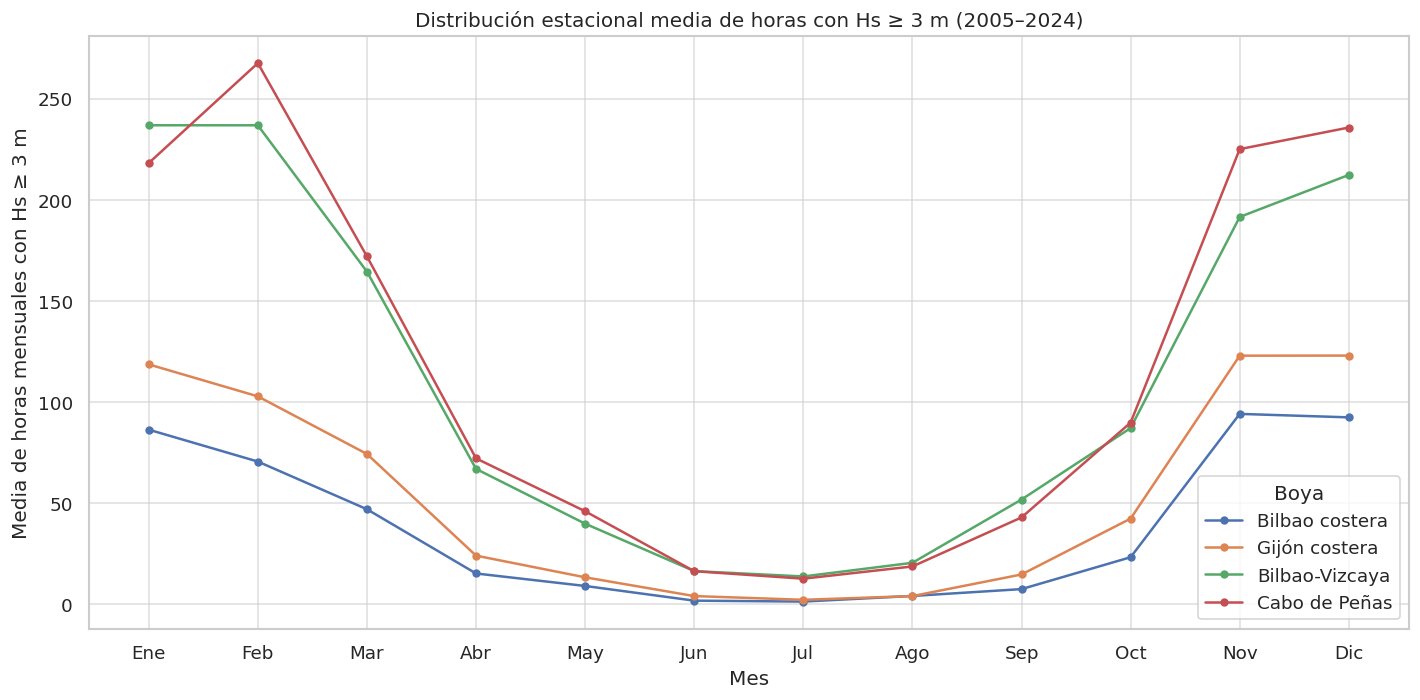

In [ ]:
# Distribución mensual MEDIA de horas con Hs ≥ 3 m
# Cada punto representa un mes tipo: media de todos los eneros, febreros, etc.

horas_mensuales_hs3_media = (
    oleaje
    .dropna(subset=['fecha', 'Hs_m'])
    .assign(
        mes_num=lambda x: x['fecha'].dt.month,
        hora_hs_ge_3m=lambda x: x['Hs_m'].ge(3)
    )
    # Primero calcula las horas de cada mes-año real
    .groupby(
        ['nombre_boya', oleaje['fecha'].dt.to_period('M'), 'mes_num'],
        as_index=False
    )['hora_hs_ge_3m']
    .sum()
    .rename(columns={'hora_hs_ge_3m': 'horas_hs_ge_3m'})
    # Después calcula la media de los 20 eneros, 20 febreros, etc.
    .groupby(['nombre_boya', 'mes_num'], as_index=False)['horas_hs_ge_3m']
    .mean()
)

plt.figure(figsize=(12, 6))

for boya in orden_boyas:
    datos = horas_mensuales_hs3_media[
        horas_mensuales_hs3_media['nombre_boya'] == boya
    ]
    plt.plot(
        datos['mes_num'],
        datos['horas_hs_ge_3m'],
        marker='o',
        markersize=4,
        linewidth=1.5,
        color=colores[boya],
        label=boya
    )

plt.xticks(range(1, 13), meses_etiqueta)
plt.xlabel('Mes')
plt.ylabel('Media de horas mensuales con Hs ≥ 3 m')
plt.title('Distribución estacional media de horas con Hs ≥ 3 m (2005–2024)')
plt.legend(title='Boya')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

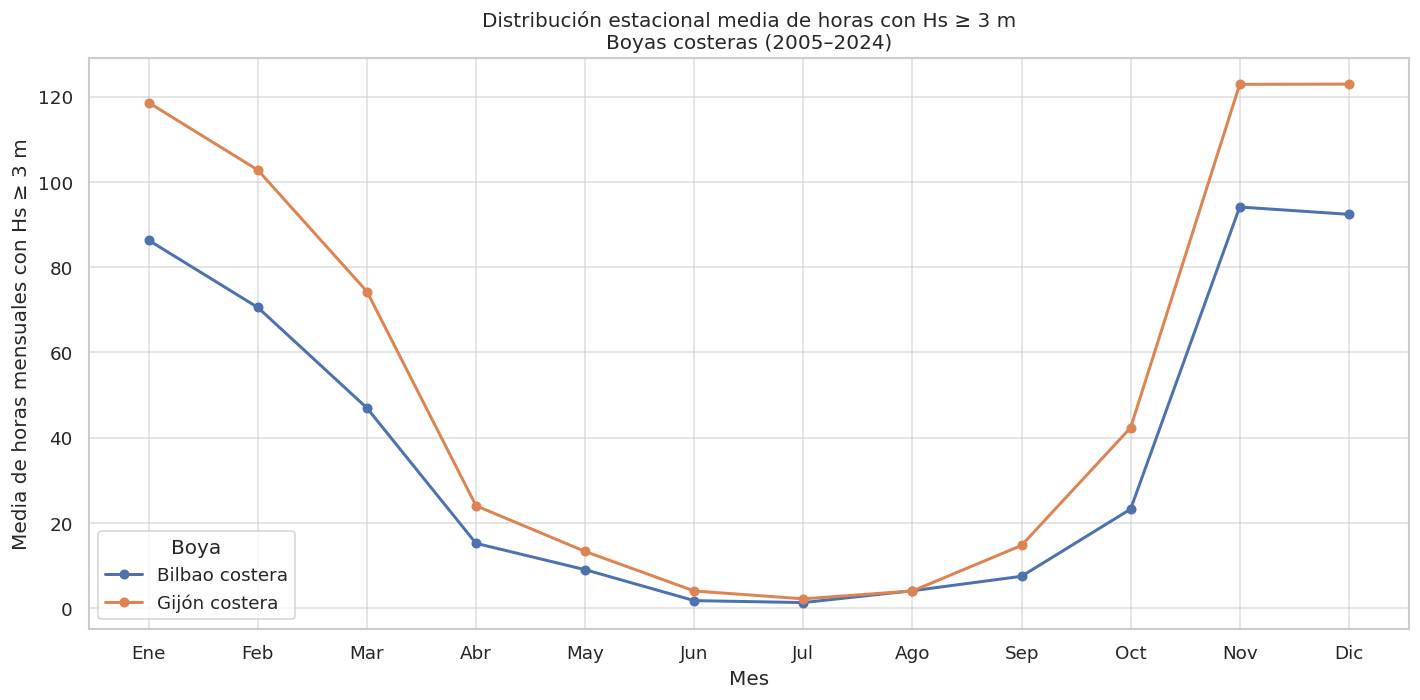

In [ ]:
# Distribución estacional media: solo boyas costeras
boyas_costeras = ['Bilbao costera', 'Gijón costera']

colores_costeras = {
    'Bilbao costera': '#4C72B0',
    'Gijón costera': '#DD8452'
}

datos_costeras = horas_mensuales_hs3_media[
    horas_mensuales_hs3_media['nombre_boya'].isin(boyas_costeras)
].copy()

plt.figure(figsize=(12, 6))

for boya in boyas_costeras:
    datos = datos_costeras[
        datos_costeras['nombre_boya'] == boya
    ].sort_values('mes_num')

    plt.plot(
        datos['mes_num'],
        datos['horas_hs_ge_3m'],
        marker='o',
        markersize=5,
        linewidth=1.8,
        color=colores_costeras[boya],
        label=boya
    )

plt.xticks(range(1, 13), meses_etiqueta)
plt.xlabel('Mes')
plt.ylabel('Media de horas mensuales con Hs ≥ 3 m')
plt.title('Distribución estacional media de horas con Hs ≥ 3 m\nBoyas costeras (2005–2024)')
plt.legend(title='Boya')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que la fecha del oleaje y los meses de tráfico son fechas
oleaje['fecha'] = pd.to_datetime(oleaje['fecha'])

for tabla in [trafico_gijon, trafico_bilbao]:
    tabla['mes'] = pd.to_datetime(tabla['mes'].astype(str).str[:7] + '-01')

def crear_tabla_puerto(codigo_boya, trafico, puerto, cobertura_minima=0.70):
    # Horas con Hs >= 3 m en cada mes real
    datos = oleaje.loc[
        (oleaje['codigo_boya'] == codigo_boya) & oleaje['Hs_m'].notna(),
        ['fecha', 'Hs_m']
    ].copy()

    datos['mes'] = datos['fecha'].dt.to_period('M').dt.to_timestamp()
    datos['hs_ge_3m'] = datos['Hs_m'] >= 3

    mensual = (
        datos.groupby('mes', as_index=False)
        .agg(
            horas_hs_ge_3m=('hs_ge_3m', 'sum'),
            horas_observadas=('Hs_m', 'size')
        )
    )

    mensual['horas_teoricas'] = mensual['mes'].apply(
        lambda x: calendar.monthrange(x.year, x.month)[1] * 24
    )
    mensual['cobertura'] = mensual['horas_observadas'] / mensual['horas_teoricas']

    # Solo se conservan meses con al menos 70 % de datos horarios disponibles
    mensual = mensual[mensual['cobertura'] >= cobertura_minima].copy()

    # Unión mes a mes con tráfico y restricciones
    tabla = trafico.merge(mensual, on='mes', how='inner')
    tabla['puerto'] = puerto
    tabla['mes_num'] = tabla['mes'].dt.month

    return tabla.sort_values('mes').reset_index(drop=True)

# Boyas costeras: Gijón 1117 y Bilbao 1103
gijon_mensual = crear_tabla_puerto(1117, trafico_gijon, 'Gijón')
bilbao_mensual = crear_tabla_puerto(1103, trafico_bilbao, 'Bilbao')

# Media de todos los eneros, febreros, etc.
columnas_media = [
    'horas_hs_ge_3m', 'horas_restriccion',
    'granel_solido_t', 'granel_liquido_t',
    'mercancia_general_t', 'contenedores_teu'
]

gijon_perfil = gijon_mensual.groupby('mes_num', as_index=False)[columnas_media].mean()
bilbao_perfil = bilbao_mensual.groupby('mes_num', as_index=False)[columnas_media].mean()

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

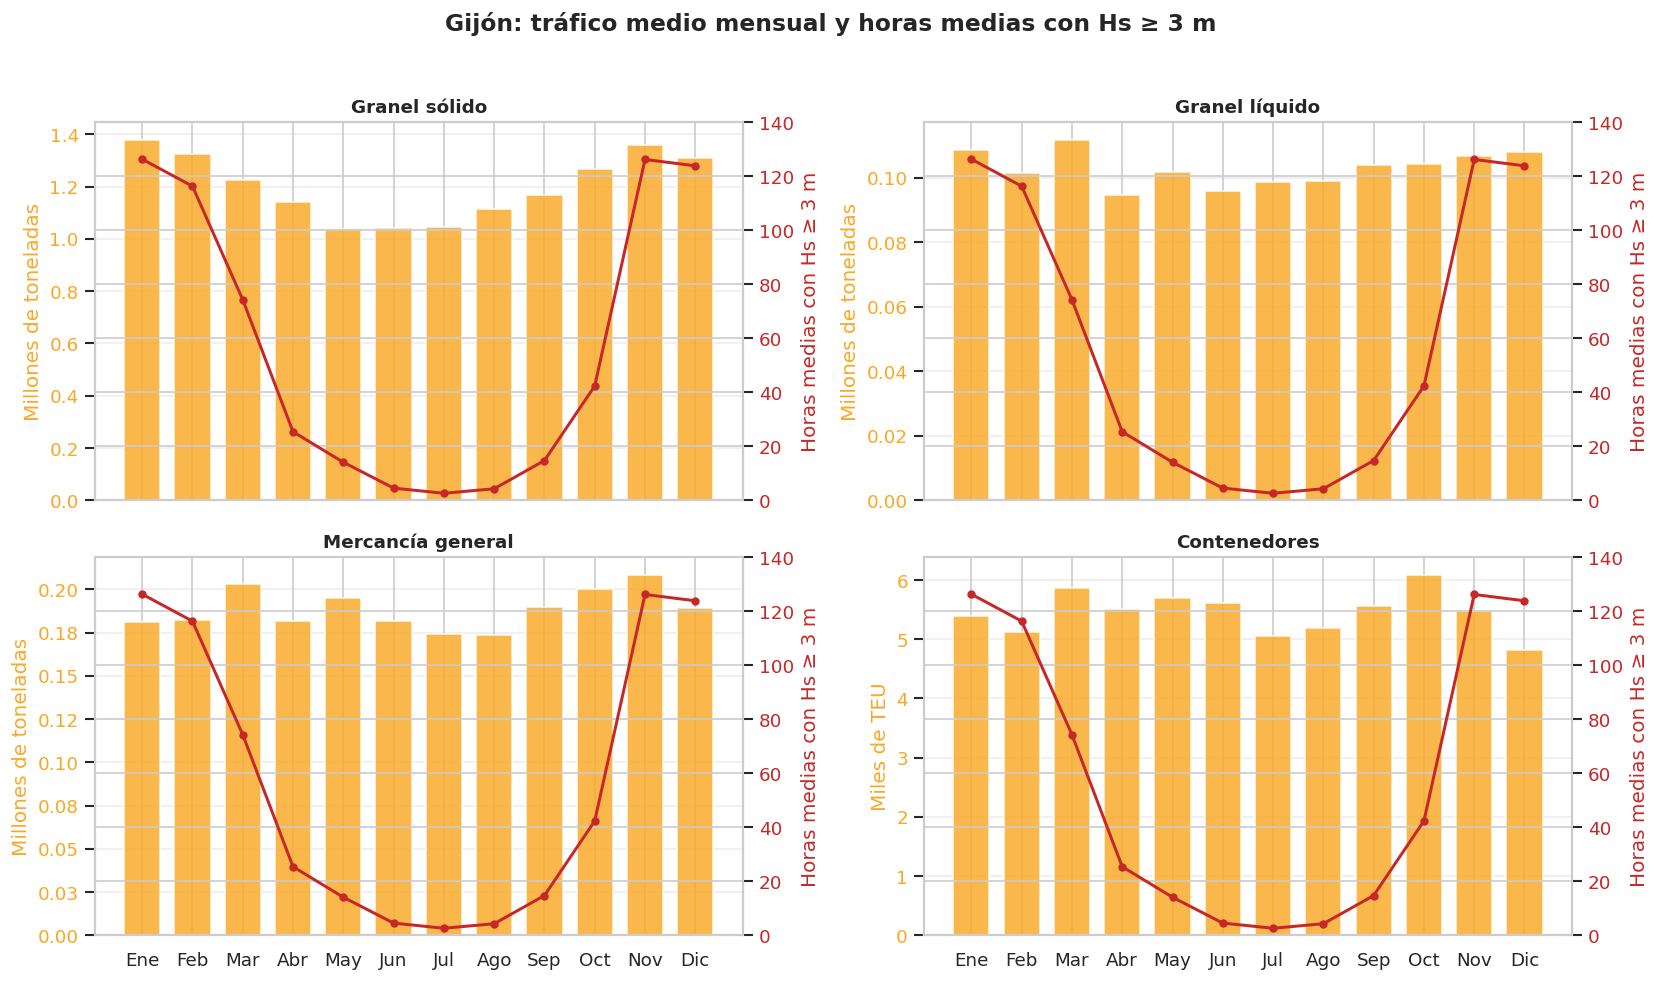

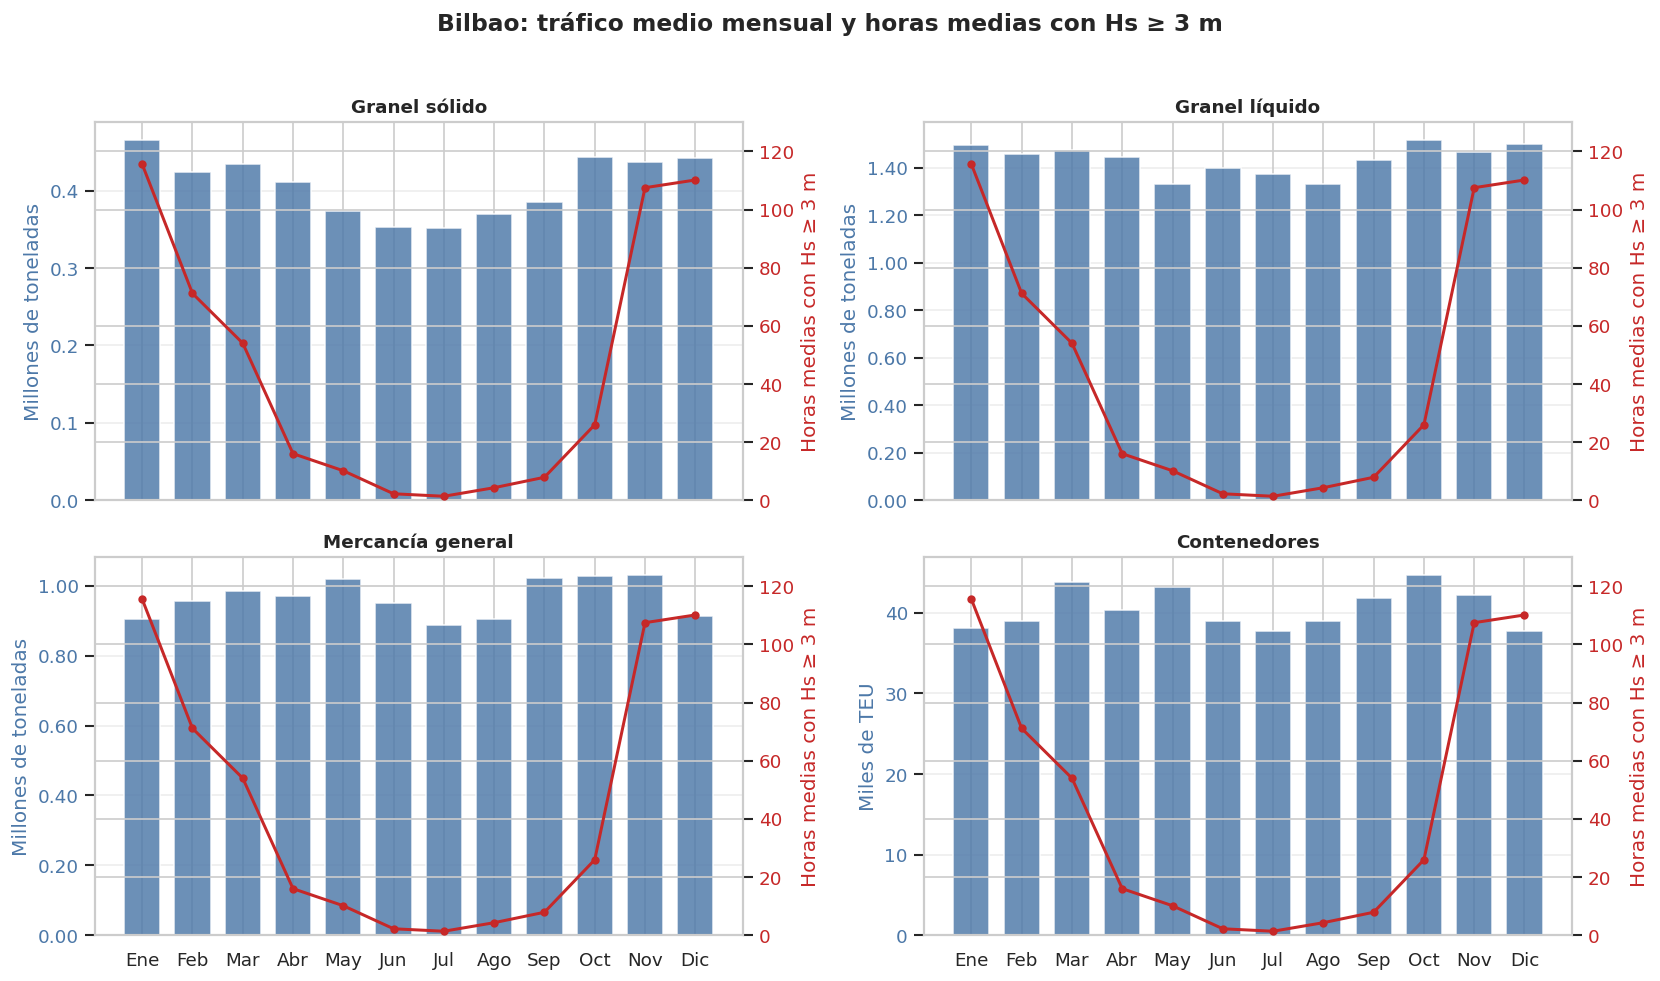

In [ ]:
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import matplotlib.pyplot as plt

def graficar_trafico_barras_oleaje_linea(perfil, puerto, color_barras):
    variables_trafico = [
        ('granel_solido_t', 'Granel sólido', 'Millones de toneladas', 1e6),
        ('granel_liquido_t', 'Granel líquido', 'Millones de toneladas', 1e6),
        ('mercancia_general_t', 'Mercancía general', 'Millones de toneladas', 1e6),
        ('contenedores_teu', 'Contenedores', 'Miles de TEU', 1e3)
    ]

    # La misma escala de oleaje en los cuatro paneles
    max_horas = perfil['horas_hs_ge_3m'].max()
    limite_horas = np.ceil(max_horas / 10) * 10 + 10

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.ravel()

    for ax, (variable, titulo, etiqueta_trafico, escala) in zip(axes, variables_trafico):

        # Barras: tráfico medio mensual
        ax.bar(
            perfil['mes_num'],
            perfil[variable] / escala,
            color=color_barras,
            alpha=0.82,
            width=0.72
        )

        ax.set_title(titulo, fontsize=11, fontweight='bold')
        ax.set_ylabel(etiqueta_trafico, color=color_barras)
        ax.tick_params(axis='y', labelcolor=color_barras)
        ax.set_ylim(bottom=0)

        # Formato adecuado para cada unidad de tráfico
        if variable == 'granel_solido_t':
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        elif variable in ['granel_liquido_t', 'mercancia_general_t']:
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

        else:  # Contenedores
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

        # Línea: horas medias mensuales con Hs >= 3 m
        ax2 = ax.twinx()
        ax2.plot(
            perfil['mes_num'],
            perfil['horas_hs_ge_3m'],
            color='#C62828',
            marker='o',
            markersize=4,
            linewidth=1.8,
            zorder=3
        )

        ax2.set_ylabel('Horas medias con Hs ≥ 3 m', color='#C62828')
        ax2.tick_params(axis='y', labelcolor='#C62828')
        ax2.set_ylim(0, limite_horas)
        ax2.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(meses)
        ax.grid(axis='y', alpha=0.35)

    fig.suptitle(
        f'{puerto}: tráfico medio mensual y horas medias con Hs ≥ 3 m',
        fontsize=14,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# Puerto de Gijón: boya costera 1117
graficar_trafico_barras_oleaje_linea(
    gijon_perfil,
    'Gijón',
    '#F9A825'
)

# Puerto de Bilbao: boya costera 1103
graficar_trafico_barras_oleaje_linea(
    bilbao_perfil,
    'Bilbao',
    '#4C78A8'
)

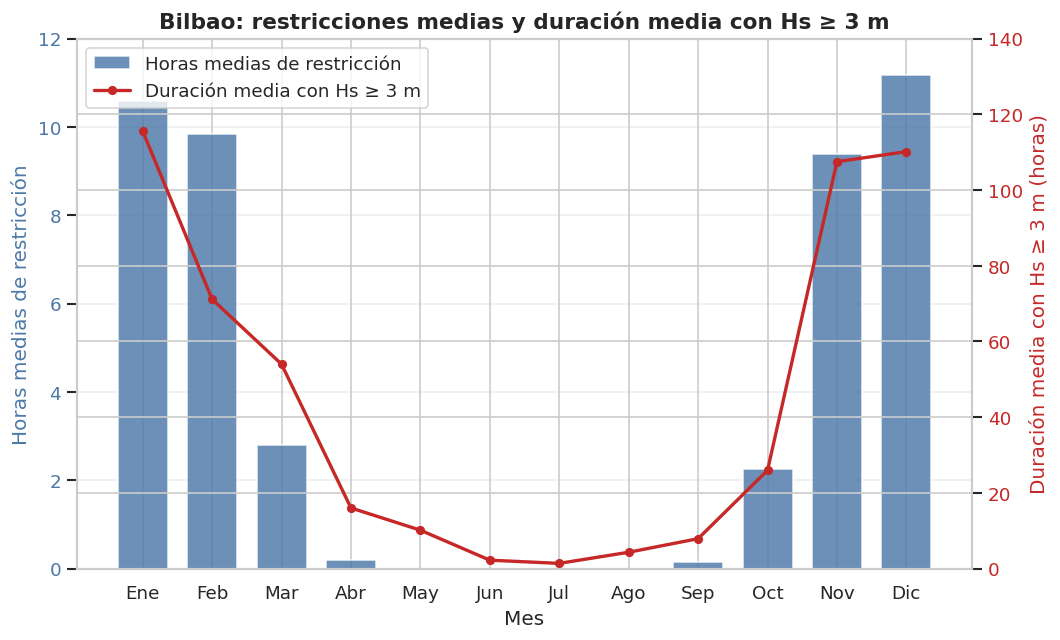

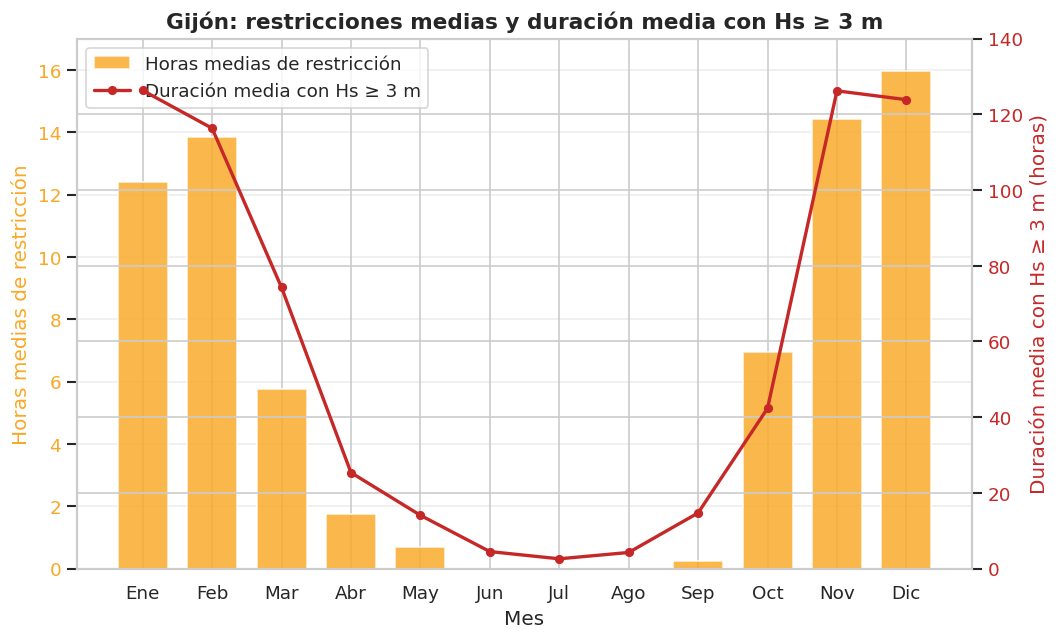

In [ ]:
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import matplotlib.pyplot as plt

def graficar_restricciones_barras_oleaje_linea(perfil, puerto, color_barras):
    # Misma escala de oleaje en ambos puertos
    limite_horas_oleaje = 140

    # Escala de restricciones adaptada a cada puerto, siempre desde cero
    if puerto == 'Bilbao':
        limite_restricciones = 12
    else:  # Gijón
        limite_restricciones = 17

    fig, ax = plt.subplots(figsize=(9, 5.5))

    # Barras: horas medias mensuales de restricción
    ax.bar(
        perfil['mes_num'],
        perfil['horas_restriccion'],
        color=color_barras,
        alpha=0.82,
        width=0.72,
        label='Horas medias de restricción'
    )

    ax.set_xlabel('Mes')
    ax.set_ylabel('Horas medias de restricción', color=color_barras)
    ax.tick_params(axis='y', labelcolor=color_barras)
    ax.set_ylim(0, limite_restricciones)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses)
    ax.grid(axis='y', alpha=0.35)

    # Línea: duración media mensual con Hs >= 3 m
    ax2 = ax.twinx()
    ax2.plot(
        perfil['mes_num'],
        perfil['horas_hs_ge_3m'],
        color='#C62828',
        marker='o',
        markersize=4.5,
        linewidth=2,
        zorder=3,
        label='Duración media con Hs ≥ 3 m'
    )

    ax2.set_ylabel('Duración media con Hs ≥ 3 m (horas)', color='#C62828')
    ax2.tick_params(axis='y', labelcolor='#C62828')
    ax2.set_ylim(0, limite_horas_oleaje)
    ax2.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    # Leyenda conjunta
    elementos_1, etiquetas_1 = ax.get_legend_handles_labels()
    elementos_2, etiquetas_2 = ax2.get_legend_handles_labels()
    ax.legend(
        elementos_1 + elementos_2,
        etiquetas_1 + etiquetas_2,
        loc='upper left'
    )

    ax.set_title(
        f'{puerto}: restricciones medias y duración media con Hs ≥ 3 m',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


# Bilbao: barras azules y boya costera 1103
graficar_restricciones_barras_oleaje_linea(
    bilbao_perfil,
    'Bilbao',
    '#4C78A8'
)

# Gijón: barras naranjas y boya costera 1117
graficar_restricciones_barras_oleaje_linea(
    gijon_perfil,
    'Gijón',
    '#F9A825'
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def preparar_pares_mensuales(tabla, puerto):
    pares = tabla[
        ['mes', 'horas_hs_ge_3m', 'horas_restriccion']
    ].dropna().copy()

    pares['mes'] = pd.to_datetime(pares['mes'])
    pares = pares.sort_values('mes').reset_index(drop=True)
    pares['puerto'] = puerto

    return pares

pares_gijon = preparar_pares_mensuales(gijon_mensual, 'Gijón')
pares_bilbao = preparar_pares_mensuales(bilbao_mensual, 'Bilbao')

print(f'Número de pares mensuales válidos en Gijón: {len(pares_gijon)}')
print(f'Número de pares mensuales válidos en Bilbao: {len(pares_bilbao)}')

display(pares_gijon.head(10))

Número de pares mensuales válidos en Gijón: 202
Número de pares mensuales válidos en Bilbao: 185


,mes,horas_hs_ge_3m,horas_restriccion,puerto
0,2005-01-01,164,16.700,Gijón
1,2005-03-01,11,7.500,Gijón
2,2005-04-01,56,1.600,Gijón
3,2005-05-01,0,0.000,Gijón
4,2005-06-01,0,0.000,Gijón
5,2005-07-01,0,0.000,Gijón
6,2005-08-01,0,0.000,Gijón
7,2005-09-01,30,0.000,Gijón
8,2005-10-01,62,4.800,Gijón
9,2005-11-01,148,14.500,Gijón


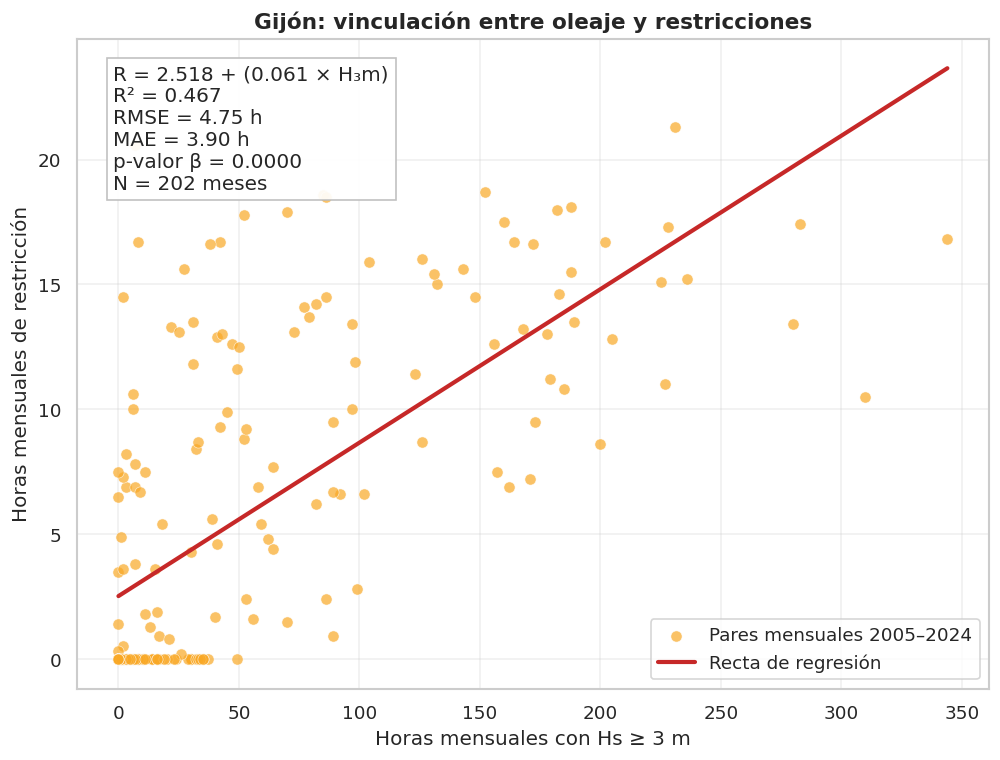

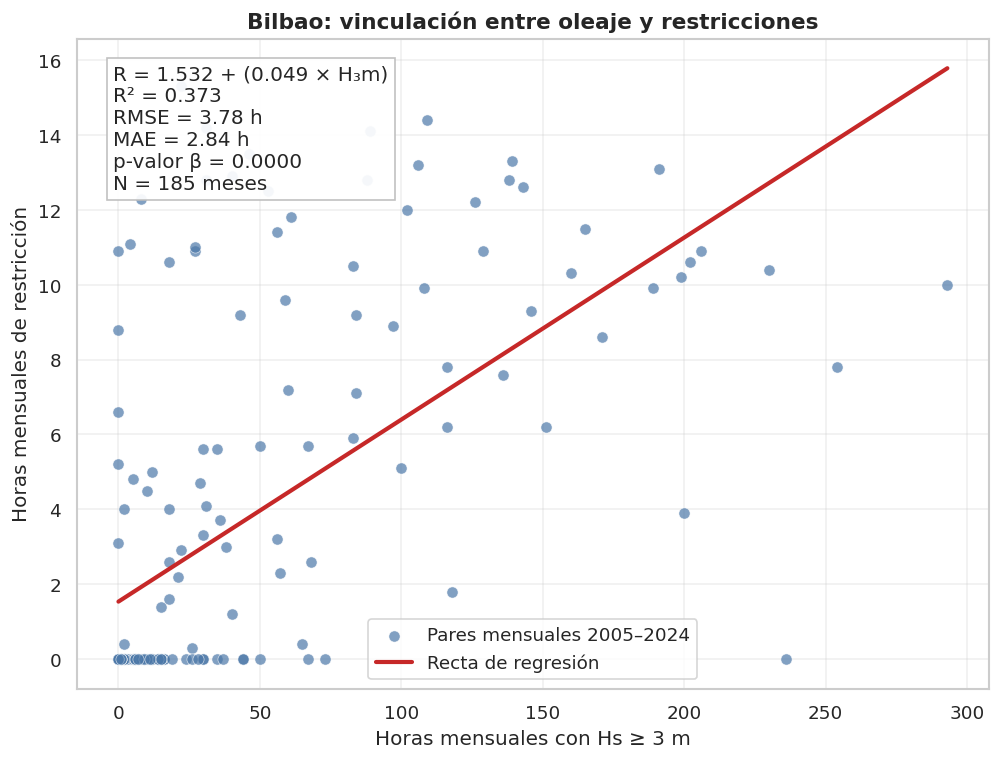

,Puerto,Función,α intercepto,β pendiente,R²,RMSE (h),MAE (h),p-valor β,Nº pares mensuales
0,Gijón,R = 2.518 + (0.061 × H₃m),2.518,0.061,0.467,4.75,3.90,0.0000,202
1,Bilbao,R = 1.532 + (0.049 × H₃m),1.532,0.049,0.373,3.78,2.84,0.0000,185


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def ajustar_recta_todos_los_pares(pares, puerto, color):
    # Todos los meses válidos disponibles
    datos = pares[
        ['mes', 'horas_hs_ge_3m', 'horas_restriccion']
    ].dropna().copy()

    datos['mes'] = pd.to_datetime(datos['mes'])
    datos = datos.sort_values('mes')

    X = datos[['horas_hs_ge_3m']]
    y = datos['horas_restriccion']

    # Ajuste de la recta con todos los pares
    modelo = LinearRegression()
    modelo.fit(X, y)

    alfa = modelo.intercept_
    beta = modelo.coef_[0]

    datos['restriccion_estimada'] = modelo.predict(X)

    # Indicadores del ajuste histórico
    _, _, _, p_valor_beta, _ = stats.linregress(
        datos['horas_hs_ge_3m'],
        datos['horas_restriccion']
    )

    r2 = r2_score(y, datos['restriccion_estimada'])
    rmse = np.sqrt(mean_squared_error(y, datos['restriccion_estimada']))
    mae = mean_absolute_error(y, datos['restriccion_estimada'])

    # Gráfico: cada punto es un mes real
    plt.figure(figsize=(8.5, 6.5))

    plt.scatter(
        datos['horas_hs_ge_3m'],
        datos['horas_restriccion'],
        color=color,
        alpha=0.70,
        s=45,
        edgecolor='white',
        linewidth=0.4,
        label='Pares mensuales 2005–2024'
    )

    x_recta = np.linspace(
        datos['horas_hs_ge_3m'].min(),
        datos['horas_hs_ge_3m'].max(),
        100
    )

    plt.plot(
        x_recta,
        alfa + beta * x_recta,
        color='#C62828',
        linewidth=2.5,
        label='Recta de regresión'
    )

    plt.xlabel('Horas mensuales con Hs ≥ 3 m')
    plt.ylabel('Horas mensuales de restricción')
    plt.title(
        f'{puerto}: vinculación entre oleaje y restricciones',
        fontsize=13,
        fontweight='bold'
    )
    plt.grid(alpha=0.30)
    plt.legend()

    texto = (
        f'R = {alfa:.3f} + ({beta:.3f} × H₃m)\n'
        f'R² = {r2:.3f}\n'
        f'RMSE = {rmse:.2f} h\n'
        f'MAE = {mae:.2f} h\n'
        f'p-valor β = {p_valor_beta:.4f}\n'
        f'N = {len(datos)} meses'
    )

    plt.text(
        0.04, 0.96, texto,
        transform=plt.gca().transAxes,
        va='top',
        bbox=dict(facecolor='white', edgecolor='#BDBDBD', alpha=0.93)
    )

    plt.tight_layout()
    plt.show()

    return {
        'Puerto': puerto,
        'Función': f'R = {alfa:.3f} + ({beta:.3f} × H₃m)',
        'α intercepto': alfa,
        'β pendiente': beta,
        'R²': r2,
        'RMSE (h)': rmse,
        'MAE (h)': mae,
        'p-valor β': p_valor_beta,
        'Nº pares mensuales': len(datos)
    }

# Gijón: boya costera 1117
resultado_final_gijon = ajustar_recta_todos_los_pares(
    pares_gijon,
    'Gijón',
    '#F9A825'
)

# Bilbao: boya costera 1103
resultado_final_bilbao = ajustar_recta_todos_los_pares(
    pares_bilbao,
    'Bilbao',
    '#4C78A8'
)

tabla_funciones = pd.DataFrame([
    resultado_final_gijon,
    resultado_final_bilbao
])

display(
    tabla_funciones.style.format({
        'α intercepto': '{:.3f}',
        'β pendiente': '{:.3f}',
        'R²': '{:.3f}',
        'RMSE (h)': '{:.2f}',
        'MAE (h)': '{:.2f}',
        'p-valor β': '{:.4f}'
    })
)

tabla_funciones.to_csv(
    'funciones_oleaje_restricciones_todos_los_pares.csv',
    index=False
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


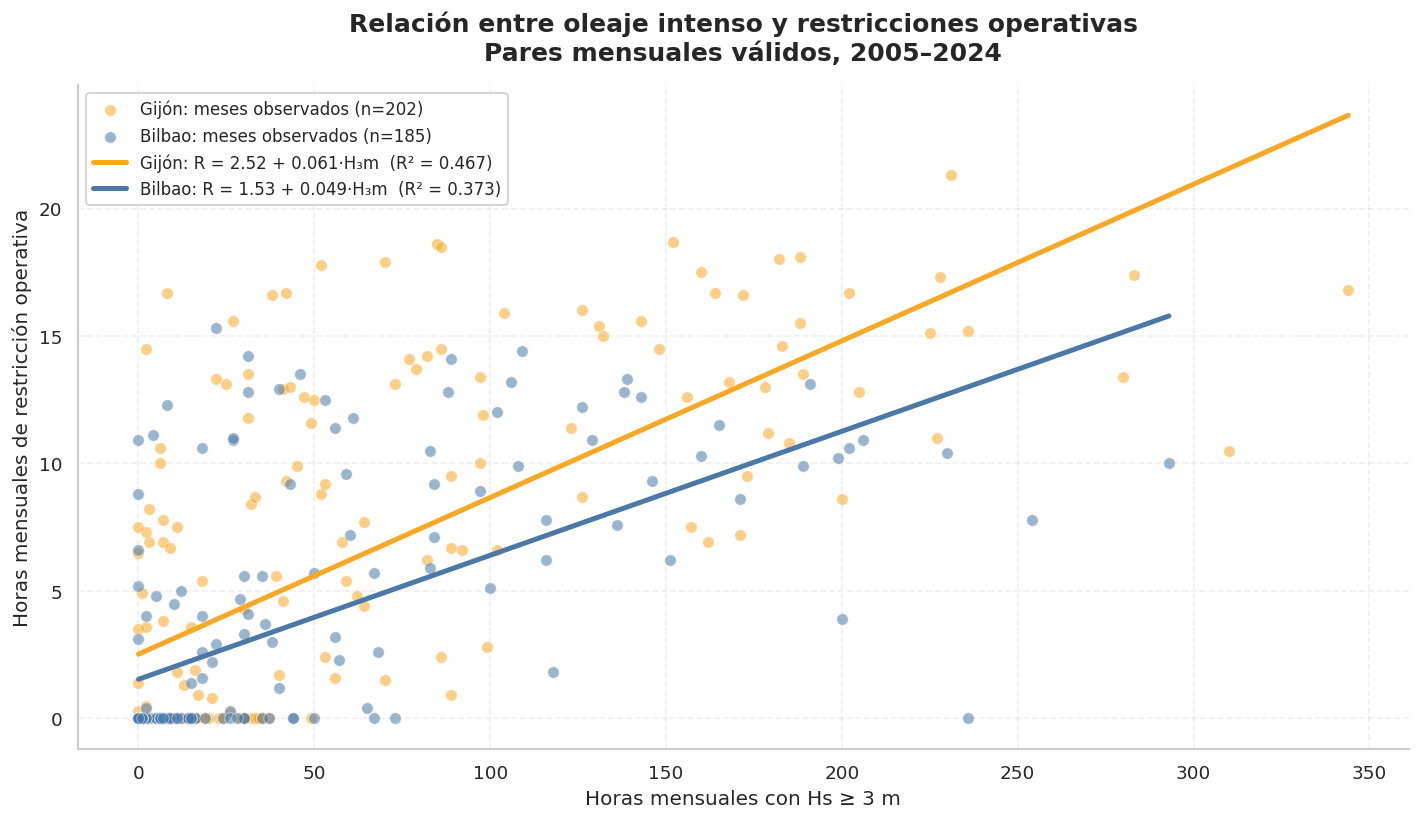

In [ ]:
# GRÁFICO CONJUNTO: horas mensuales Hs ≥ 3 m frente a restricciones
# Cada punto representa un mes real válido (cobertura de oleaje ≥ 70 %)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def preparar_y_ajustar(pares, nombre, color):
    datos = pares[['mes', 'horas_hs_ge_3m', 'horas_restriccion']].dropna().copy()

    X = datos[['horas_hs_ge_3m']]
    y = datos['horas_restriccion']

    modelo = LinearRegression()
    modelo.fit(X, y)

    alfa = modelo.intercept_
    beta = modelo.coef_[0]
    r2 = modelo.score(X, y)

    # Línea de regresión
    x_linea = np.linspace(datos['horas_hs_ge_3m'].min(),
                          datos['horas_hs_ge_3m'].max(), 200)
    y_linea = modelo.predict(x_linea.reshape(-1, 1))

    return {
        'datos': datos,
        'nombre': nombre,
        'color': color,
        'alfa': alfa,
        'beta': beta,
        'r2': r2,
        'x_linea': x_linea,
        'y_linea': y_linea
    }

# Ajuste con TODOS los pares mensuales válidos
gijon = preparar_y_ajustar(pares_gijon, 'Gijón', '#F9A825')
bilbao = preparar_y_ajustar(pares_bilbao, 'Bilbao', '#4C78A8')

# Gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Puntos mensuales
ax.scatter(
    gijon['datos']['horas_hs_ge_3m'],
    gijon['datos']['horas_restriccion'],
    color=gijon['color'],
    alpha=0.55,
    s=48,
    edgecolor='white',
    linewidth=0.5,
    label=f"Gijón: meses observados (n={len(gijon['datos'])})"
)

ax.scatter(
    bilbao['datos']['horas_hs_ge_3m'],
    bilbao['datos']['horas_restriccion'],
    color=bilbao['color'],
    alpha=0.55,
    s=48,
    edgecolor='white',
    linewidth=0.5,
    label=f"Bilbao: meses observados (n={len(bilbao['datos'])})"
)

# Rectas de regresión
ax.plot(
    gijon['x_linea'], gijon['y_linea'],
    color=gijon['color'],
    linewidth=3,
    label=f"Gijón: R = {gijon['alfa']:.2f} + {gijon['beta']:.3f}·H₃m  (R² = {gijon['r2']:.3f})"
)

ax.plot(
    bilbao['x_linea'], bilbao['y_linea'],
    color=bilbao['color'],
    linewidth=3,
    label=f"Bilbao: R = {bilbao['alfa']:.2f} + {bilbao['beta']:.3f}·H₃m  (R² = {bilbao['r2']:.3f})"
)

ax.set_title(
    'Relación entre oleaje intenso y restricciones operativas\n'
    'Pares mensuales válidos, 2005–2024',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Horas mensuales con Hs ≥ 3 m', fontsize=12)
ax.set_ylabel('Horas mensuales de restricción operativa', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    loc='upper left',
    fontsize=10,
    frameon=True,
    framealpha=0.95
)

plt.tight_layout()
plt.show()

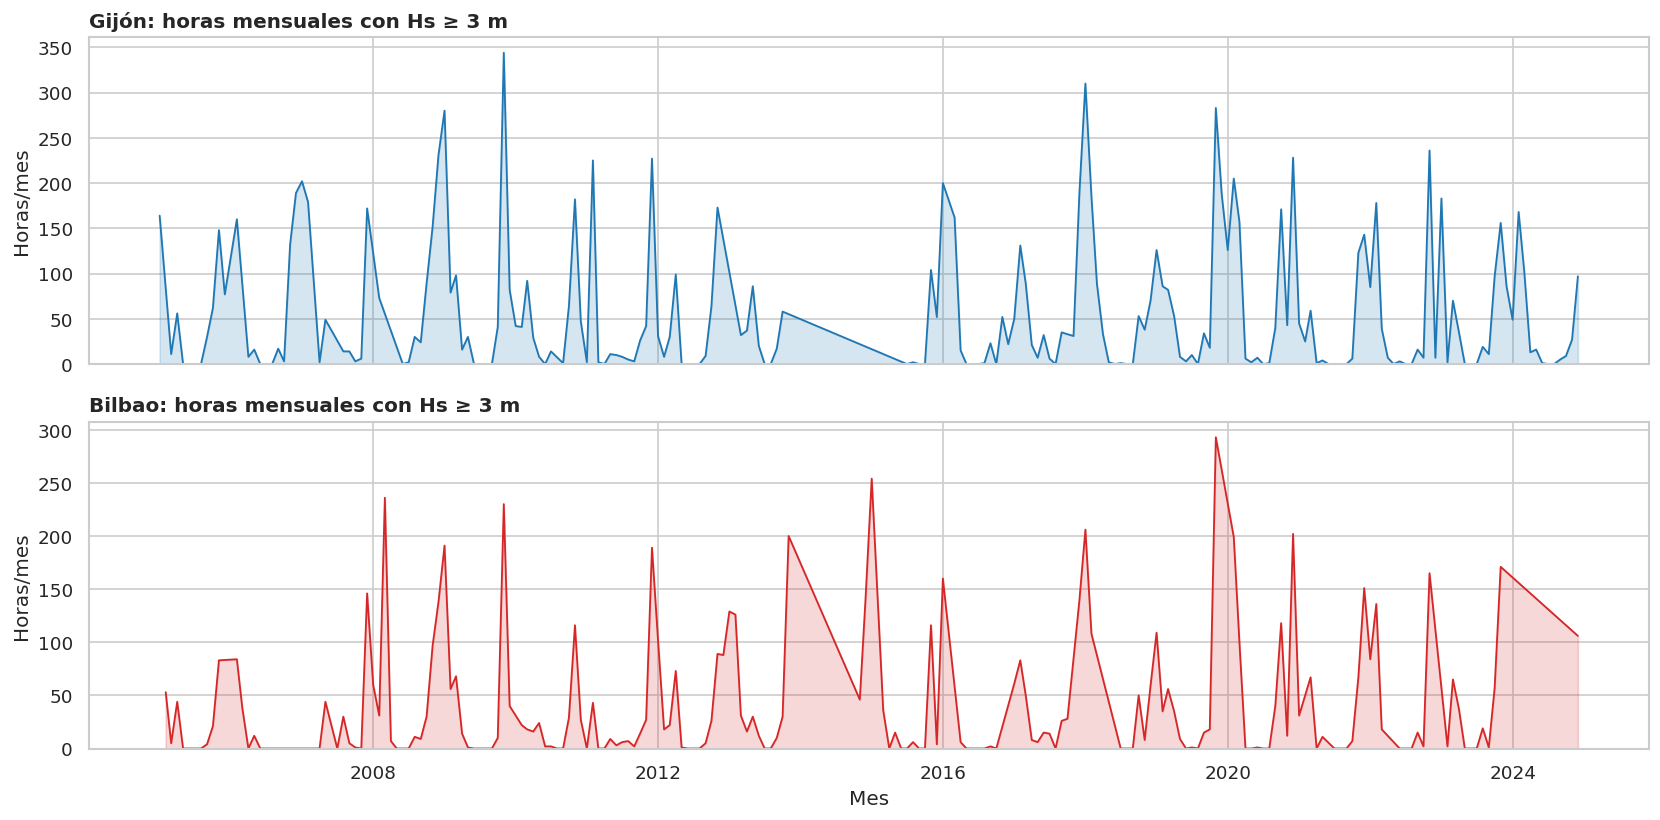

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, datos, puerto, color in [
    (axes[0], exposicion_gijon, 'Gijón', '#1f77b4'),
    (axes[1], exposicion_bilbao, 'Bilbao', '#d62728')
]:
    ax.plot(datos['mes'], datos['horas_hs_ge_3m'], color=color, linewidth=1.1)
    ax.fill_between(datos['mes'], datos['horas_hs_ge_3m'], color=color, alpha=0.18)
    ax.set_title(f'{puerto}: horas mensuales con Hs ≥ 3 m', loc='left', fontweight='bold')
    ax.set_ylabel('Horas/mes')
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel('Mes')
plt.tight_layout()
plt.show()
